# Predicting Distance Matrix Between Amino Acids Within a Protein

## Get a Correct Distance Matrix

Dowload 10 proteins

In [1]:
MAX_LENGTH_PROTEIN = 200

In [ ]:
from general_preprocess.GetAndSaveNpArrays import GetAndSaveNpArrays

_ = GetAndSaveNpArrays(100, MAX_LENGTH_PROTEIN, 0.2, "./data/dataTests")

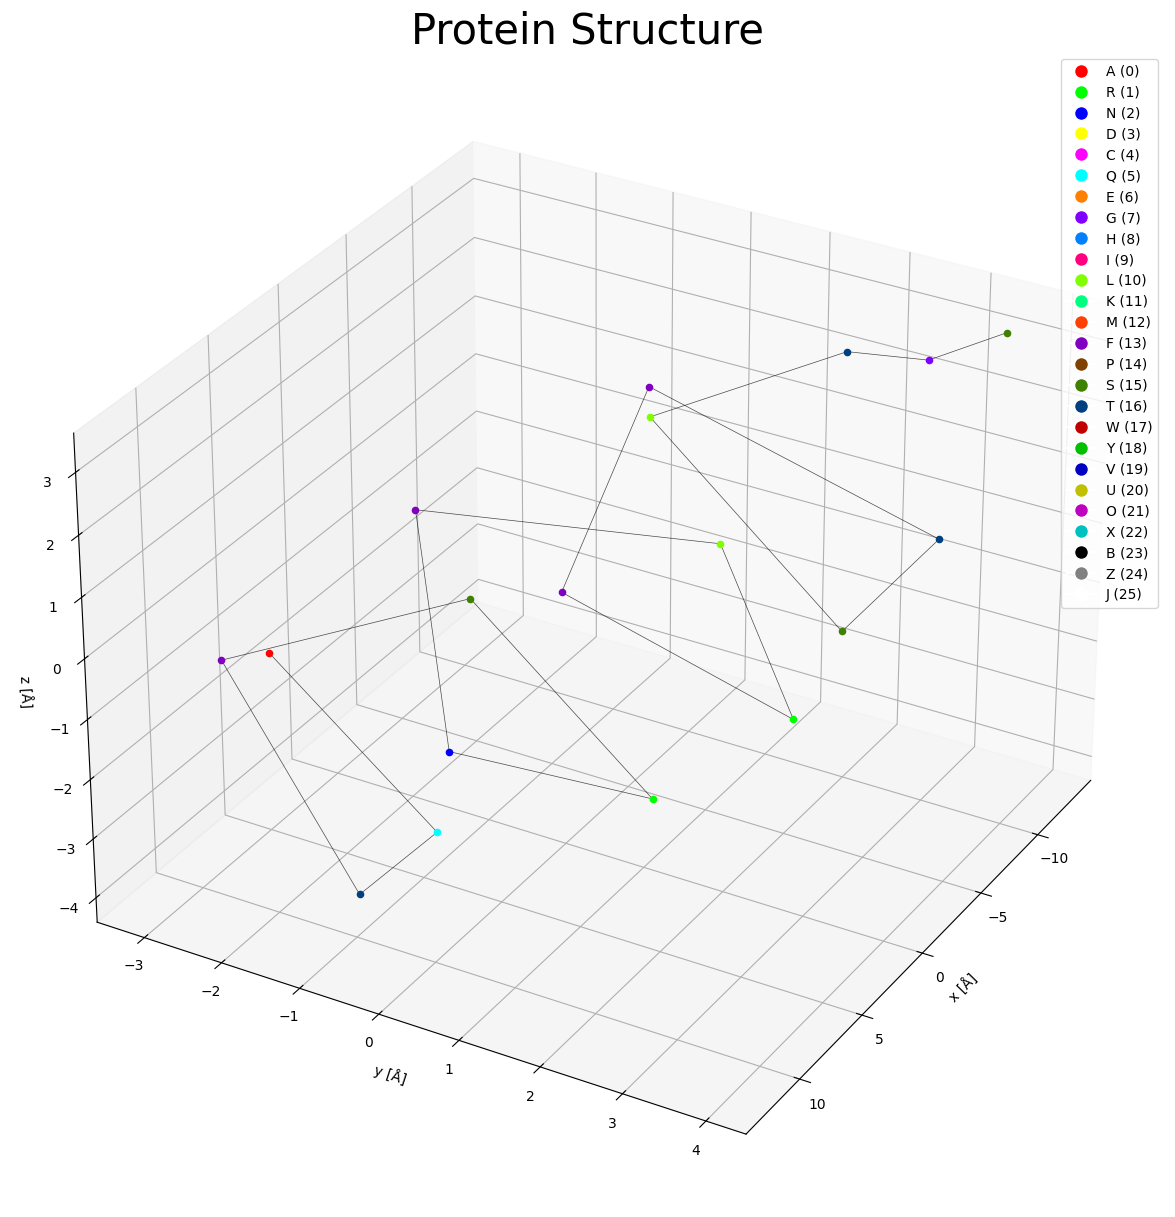

In [7]:
import numpy as np
from distance_matrix.show.PlotOneProtein import PlotOneProtein

CaCoords_arr = np.load("./data/2_50/np_arrays/CaCoordinates.npy", allow_pickle=True)
AminoAcids_arr = np.load("./data/2_50/np_arrays/AminoAcids.npy", allow_pickle=True)

PlotOneProtein(1, CaCoords_arr, AminoAcids_arr)

In [3]:
from preprocess.CalculateDistanceMatrix import CalculateDistanceMatrix
import matplotlib.pyplot as plt 

distanceMatrix = CalculateDistanceMatrix(CaCoords_arr[0], len(CaCoords_arr[0])+100)
# plt.imshow(distanceMatrix)
# plt.show()

In [4]:
from preprocess.CalculateAngles import CalculateNeighbourAngles
angleArr = CalculateNeighbourAngles(CaCoords_arr[0], len(CaCoords_arr[0])+100)
# print(np.rad2deg(angleArr))

To get 3D coordinates we first predict (relative inbetween atoms) geometric data supervised to then use this information to get the 3D coordinates

In [5]:
from preprocess.GetInputsAndTargets import GetInputVectorsAndTargetVectors

inputVectors, targetCoordinates = GetInputVectorsAndTargetVectors(CaCoords_arr, AminoAcids_arr, maxLengthProtein=MAX_LENGTH_PROTEIN)

In [6]:
from preprocess.ConvertToTensor import ConvertToTensorDataSetAndDataLoader

inputTensors, targetTensors, dataset, dataloader = ConvertToTensorDataSetAndDataLoader(CaCoords_arr, inputVectors, MAX_LENGTH_PROTEIN)

print(inputTensors.shape)
print(targetTensors.shape)


torch.Size([22, 200])
torch.Size([22, 40000])


In [ ]:
from model.architecture.encoderOnlyTransformer.EncoderOnlyTransformer import EncoderOnlyTransformer

model  = EncoderOnlyTransformer(MAX_LENGTH_PROTEIN, d_model = 100)



In [8]:
from model.train.trainTE import trainTE

model = trainTE(model, dataloader)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | we             | Embedding        | 20.0 K | train
1 | pe          

Training: |          | 0/? [00:00<?, ?it/s]

residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])

`Trainer.fit` stopped: `max_epochs=30` reached.


residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])
Output shape before flattening: torch.Size([1, 200, 200])
Output shape after flattening: torch.Size([1, 40000])
Labels shape: torch.Size([1, 40000])
residualoutput:  torch.Size([1, 200, 100])
mlpoutput:  torch.Size([1, 200, 200])

AAseq -> encode -> repeat so forms matrix -> run matrix through encoder decoder transformer

First test if only distance matrix -> Carbon alpha coordinates possible